In [24]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("./digit-recognizer/train.csv")
X = df.drop(columns='label')
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42
)
X_train = np.array(X_train) / 255.0
X_test = np.array(X_test) / 255.0
X_train.shape

(33600, 784)

In [3]:
def one_hot_encoding(y):
  return pd.get_dummies(y, dtype=int).to_numpy()
# one_hot_encoding(y_train)

In [4]:
def ReLu(X):
  return np.maximum(0, X)

def ReLu_derive(X):
  return (X > 0).astype(float)

def softmax(X):
  exp = np.exp(X - np.max(X, axis=1, keepdims=True))
  return exp / np.sum(exp, axis=1, keepdims=True)

In [5]:
class Layer:
  def __init__(
    self,
    n_nodes, 
    n_prev_nodes,
    act_func,
    act_deriv=None
  ):
    self.n_nodes = n_nodes
    self.n_prev_nodes = n_prev_nodes
    self.act_func = act_func
    self.act_deriv = act_deriv
    self.W = np.random.rand(n_prev_nodes, n_nodes) - .5
    self.b = np.random.rand(1, n_nodes) - .5
    self.input = None
    self.A = None
    self.Z = None

  def calculate(self, X):
    self.input = X
    self.Z = X.dot(self.W) + self.b
    self.A = self.act_func(self.Z)
    return self.A
  
  def update_params(self, dw, db, alpha):
    self.W = self.W - alpha*dw
    self.b = self.b - alpha*db


In [11]:
class Model:
  def __init__(self, iterations, alpha):
    self.iterations = iterations
    self.alpha = alpha
    self.layers = []
  
  def add_layer(self, layer):
    self.layers.append(layer)
    
  def forward_prop(self, X):
    curr_A = X
    for layer in self.layers:
      # print(layer.W.shape)
      curr_A = layer.calculate(curr_A)
      # print("Curr_A:")
      # print(curr_A)
    return curr_A
    
  def predict(self, X):
    y_pred = self.forward_prop(X)
    return np.argmax(y_pred, axis=1)
  
  def accuracy(self, X, y):
    predictions = self.predict(X)
    return np.mean(predictions == y)  
  
  def _backward_prop(self, y_train, y_pred, m):
    one_hot_y = one_hot_encoding(y_train)
    dZ = y_pred - one_hot_y
    for i in reversed(range(len(self.layers))):
      layer = self.layers[i]
      dW = (1/m)*layer.input.T.dot(dZ)
      db = (1/m)*np.sum(dZ, axis=0, keepdims=True)
      # print(db)
      if i != 0:
        prev_layer = self.layers[i-1]
        dA_prev = dZ.dot(layer.W.T)
        dZ = dA_prev*prev_layer.act_deriv(prev_layer.Z)
      layer.update_params(dW, db, self.alpha)
  
  def fit(self, X_train, y_train):
    m, _ = X_train.shape
    for i in range(self.iterations):
      y_pred = self.forward_prop(X_train)
      self._backward_prop(y_train, y_pred, m)

      if i % 10 == 0:
        pred = self.predict(X_train)
        print(np.mean(pred == y_train))
  
model = Model(
  500,
  0.1
)
l1 = Layer(10, 784, ReLu, ReLu_derive)
l2 = Layer(10, 10, softmax)
model.add_layer(l1)
model.add_layer(l2)
model.fit(X_train, y_train)

0.10211309523809524
0.19842261904761904
0.2978571428571429
0.3645535714285714
0.4164285714285714
0.46473214285714287
0.5099107142857143
0.550625
0.5844047619047619
0.6129166666666667
0.6381845238095238
0.6597321428571429
0.6780654761904762
0.6922321428571429
0.7055654761904762
0.7169940476190476
0.7268154761904762
0.7359821428571428
0.7438690476190476
0.7518154761904762
0.7579166666666667
0.7647321428571429
0.7694940476190476
0.7742559523809524
0.7780059523809524
0.7825892857142858
0.7864880952380953
0.7898511904761905
0.7927380952380952
0.7962202380952381
0.7985416666666667
0.8020238095238095
0.805
0.8075
0.8103571428571429
0.8132440476190477
0.8152083333333333
0.8175297619047619
0.8199404761904762
0.8217857142857142
0.8236011904761905
0.8251785714285714
0.8270833333333333
0.8288690476190477
0.8301488095238095
0.8313690476190476
0.8326488095238095
0.8340178571428571
0.835297619047619
0.8363690476190476


In [22]:
train_acc = model.accuracy(X_train, y_train)
print(f"Train Accuracy: {train_acc:.4f}")

test_acc = model.accuracy(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

Train Accuracy: 0.8375
Test Accuracy: 0.8321


# Testing the model

In [42]:
def show_digit(X, y=None, index=0):
	image = X[index].reshape(28, 28)

	plt.figure(figsize=(4, 4))
	plt.imshow(image, cmap="gray")
	plt.axis("off")

	if y is not None:
		plt.title(f"Label: {y[index]}")

	plt.show()

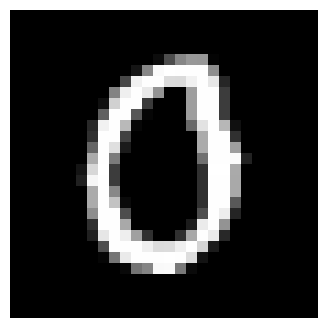

np.int64(0)

In [63]:
test_df = pd.read_csv("./digit-recognizer/test.csv")
X = np.array(test_df)/255.0
show_digit(X, index=100)
pred = model.predict(X)
pred[100]